# Cohen MWU power — all cell types

Assesses MWU power (TPR) as a function of CRE activity relative to `minP`, for every cell type in the Cohen dataset.

Cohen is an **episomal** MPRA: all CREs are transfected into all cell types (no integrating bottleneck).
Therefore we run **one set of simulations** with all cell types included, rather than separate per-cell-type runs.
Each simulation draws the same synthetic CREs into all cell types with identical activities (`n_cres` confirmed
uniform across cell types in the empirical data).

Steps:
1. Draw `n_cres` synthetic CREs from uniform(min_activity, max_activity), one fixed at `minP` as reference
2. Replicate the same CREs across all cell types in the ground truth
3. Simulate `n_sims` replicates × `n_library_reps` independent libraries using empirical Cohen bounds
4. Run MWU for all CREs vs. reference (one shared hypothesis set, all cell types)
5. Aggregate and plot per-cell-type power curves

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
import math

2026-03-21 16:27:58.531231: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-21 16:27:58.596889: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-21 16:27:58.596913: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
data_root = Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

In [3]:
cluster = SLURMCluster(
    cores=1,
    memory="64G",
    processes=1,
    job_extra_directives=[
        "-p priority",
        "-A prio_skr2",
        "--job-name=simclust_worker",
        "--time=6:00:00",
        "--output=worker_%j.out"
    ]
)
cluster.scale(jobs=12)
client = Client(cluster)

In [4]:
client.dashboard_link

'http://10.18.22.85:8787/status'

In [5]:
# Load training data to confirm n_cres is uniform across cell types (episomal check)
cohen_data = pd.read_parquet(
    data_root / "cohen_ortho" / "retina_single_counting_u6.scmpra",
    columns=["cell_type", "cre_id"]
)
n_cres_by_ct = cohen_data.groupby("cell_type")["cre_id"].nunique()
print("n_cres per cell type (should be uniform):")
print(n_cres_by_ct)
assert n_cres_by_ct.nunique() == 1, "n_cres not uniform across cell types — episomal assumption violated!"

n_cres = int(n_cres_by_ct.iloc[0])
cell_types = list(scm.COHEN_BOUNDS.cells_per_cell_type.index)
print(f"\nn_cres={n_cres}, cell_types={cell_types}")
del cohen_data

n_cres per cell type (should be uniform):
cell_type
Bipolar         115
Interneuron     115
Mueller Glia    115
Rod             115
Name: cre_id, dtype: int64

n_cres=115, cell_types=['Bipolar', 'Interneuron', 'Mueller Glia', 'reference']


In [6]:
sim_date      = "2026-03-21"
n_library_reps = 100
n_sims         = 5
minP           = scm.COHEN_BOUNDS.reference_activity
# Activity range chosen to capture full power curve on both sides of FC=1.
# Left side (FC<1) reaches ~0.8 power around FC≈0.75; right side mirrors at FC≈1.25.
# Range 0.5*minP–1.6*minP gives comfortable margin to see full S-curve.
# min_activity = scm.COHEN_BOUNDS.min_mpra_umi  # old: too wide, squashes transition zone
min_activity   = minP * 0.5
max_activity   = minP * 1.6
print(f"minP={minP:.6f}, min={min_activity:.6f}, max={max_activity:.6f}")

minP=1.201954, min=0.600977, max=1.923126


In [7]:
# Cohen is episomal: same CREs transfected into all cell types.
#
# Each batch is fully completed (gamut → save → mwu → save) before the next
# starts. Sim objects are discarded after each batch; only (location, name)
# tuples are retained. This keeps main-process memory flat regardless of how
# many batches have run.
#
# RESUME LOGIC (Run 11): scan the output dir for sims that already have MWU
# complete and pre-populate sim_paths. Only fresh sims are submitted.

def _process_batch(batch, hs_all_ct):
    """Block until batch is computed, run MWU, save, return paths."""
    for s in batch:
        s.save()

    if hs_all_ct is None:
        example_data = scm.scMPRA_data.from_parquet(batch[0].scmpradatp / "0.scmpra")
        hs_all_ct = scm.make_all_by_celltype_hypotheses(
            counts=example_data, reference_cre="reference"
        )

    for s in batch:
        s.add_hypothesis_set("hs_all_ct", hs_all_ct)
        s.mwu("hs_all_ct")
    for s in batch:
        s.save()

    return hs_all_ct, [(s.location, s.name) for s in batch]


batch_size = 10
hs_all_ct = None
batch = []

# --- Resume: collect already-completed sims from disk ---
sim_dir = data_root / f"{sim_date}_cohen_pow"
sim_paths = []
if sim_dir.exists():
    for d in sorted(sim_dir.iterdir()):
        mwu_dir = d / "tests" / "hs_all_ct" / "mwu"
        if mwu_dir.exists() and any(mwu_dir.iterdir()):
            sim_paths.append((sim_dir, d.name))
print(f"Resuming: found {len(sim_paths)} already-complete sims on disk.")
# --- End resume block ---

n_remaining = n_library_reps - len(sim_paths)
print(f"Will run {n_remaining} fresh sims to reach {n_library_reps} total.")

# for i in range(n_library_reps):   # original — runs all 100 from scratch
for i in range(n_remaining):
    rng = np.random.default_rng()

    cre_gt = rng.uniform(min_activity, max_activity, size=n_cres - 1)
    cre_gt = np.append(cre_gt, minP)
    names  = [f"synthcre_{j}" for j in range(n_cres - 1)] + ["reference"]

    gt_df = pd.concat([
        pd.DataFrame({"cre_id": names, "mu": cre_gt, "cell_type": ct})
        for ct in cell_types
    ], ignore_index=True)

    libraries = [
        scm.simulate_library(CREs=pd.Series(names), library_model=scm.COHEN_BOUNDS.library_model)
        for _ in range(n_sims)
    ]

    sim = scm.de_novo_simulation(
        location=data_root / f"{sim_date}_cohen_pow",
        name=f"sim_{uuid.uuid4().hex[:8]}",
        client=client,
        libraries=libraries,
        library_mapping="corresponding",
        flatten_overtransfection=True,
        n_sims=n_sims,
        experiment_bounds=scm.COHEN_BOUNDS,
        ground_truth=gt_df,
    )
    sim.gamut()
    batch.append(sim)

    if len(batch) == batch_size:
        hs_all_ct, paths = _process_batch(batch, hs_all_ct)
        sim_paths.extend(paths)
        batch = []
        print(f"Batch done — {len(sim_paths)}/{n_library_reps} complete.", flush=True)

if batch:
    hs_all_ct, paths = _process_batch(batch, hs_all_ct)
    sim_paths.extend(paths)
    print(f"Batch done — {len(sim_paths)}/{n_library_reps} complete.", flush=True)

print(f"All {len(sim_paths)} sims done and tested.", flush=True)

Resuming: found 0 already-complete sims on disk.
Will run 100 fresh sims to reach 100 total.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_c17caf0d'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_1130790b'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_b42aa4fc'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_d4bc2ccb'. Initalizing new object.


...

scMPRAforge: INFO: No 'state.parquet' found for 'sim_60a64c62'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_480f81a2'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_914ad82c'. Initalizing new object.


Batch done — 100/100 complete.


All 100 sims done and tested.


In [8]:
# Sims saved (twice: post-gamut and post-mwu) inside the batch loop above.

In [9]:
# MWU run per batch inside the simulate loop above.

In [10]:
# Reload sim handles from disk — objects were discarded after each batch.
sims = [
    scm.de_novo_simulation(location=loc, name=name, client=client)
    for loc, name in sim_paths
]

# Aggregate results, preserving cell type (sum_pow drops it, so we roll our own)
def sum_pow_by_ct(sims, hypothesis_set_name, test_type):
    """Like sum_pow but returns a dict of {cell_type -> DataFrame(reject_null, fc)}."""
    rows = []
    for sim in sims:
        for i in range(sim.get_state_field("n_sims")):
            m = sim._merge_in_ground_truth(hypothesis_set_name, test_type, i)
            m["fc"] = m["comparison_truth"] / m["reference_truth"]
            rows.append(m[["comparison_cell_type", "reject_null", "fc"]])
    combined = pd.concat(rows, ignore_index=True)
    return {
        ct: combined[combined["comparison_cell_type"] == ct][["reject_null", "fc"]].reset_index(drop=True)
        for ct in cell_types
    }

all_mergy = sum_pow_by_ct(sims, "hs_all_ct", "mwu")
print({ct: len(df) for ct, df in all_mergy.items()})

scMPRAforge: INFO: 'state.parquet' found for 'sim_c17caf0d', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_1130790b', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_b42aa4fc', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_d4bc2ccb', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_cd233e0d', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'sim_4e37b8c2', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_60a64c62', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_480f81a2', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_914ad82c', loading.


{'Bipolar': 57000, 'Interneuron': 57000, 'Mueller Glia': 57000, 'reference': 57000}


Saved: output/power_mwu_all_cell_types.svg


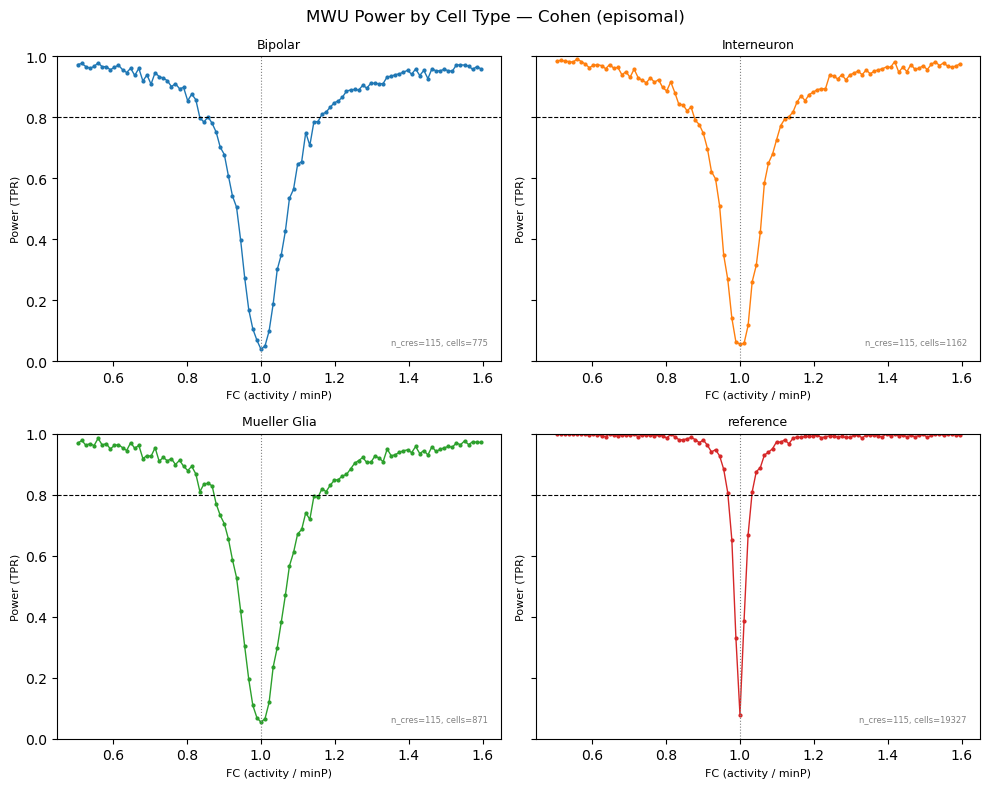

In [11]:
def _pow_curve_data(mergy, n_bins=100):
    df = mergy.copy()
    df["fc"] = pd.cut(df["fc"], bins=n_bins)
    binned = (
        df.groupby("fc", observed=True)["reject_null"]
        .mean()
        .reset_index(name="reject_frac")
    )
    binned["bin_center"] = binned["fc"].apply(lambda x: x.mid)
    return binned

ncols = 2
nrows = math.ceil(len(cell_types) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
palette = sns.color_palette("tab10", n_colors=len(cell_types))

for i, ct in enumerate(cell_types):
    ct_display = "Rod" if ct == "reference" else ct
    binned = _pow_curve_data(all_mergy[ct])
    ax = axes[i]
    ax.plot(binned["bin_center"], binned["reject_frac"],
            color=palette[i], marker="o", markersize=2, linewidth=1)
    ax.axhline(0.8, color="black", linestyle="--", lw=0.8)
    ax.axvline(1.0, color="grey",  linestyle=":",  lw=0.8)
    ax.set_title(ct_display, fontsize=9)
    ax.set_xlabel("FC (activity / minP)", fontsize=8)
    ax.set_ylabel("Power (TPR)", fontsize=8)
    ax.set_ylim(0, 1)
    cells = scm.COHEN_BOUNDS.cells_per_cell_type.get(ct, "?")
    ax.text(0.97, 0.05,
            f"n_cres={n_cres}, cells={cells}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color="grey")

for j in range(len(cell_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("MWU Power by Cell Type — Cohen (episomal)", fontsize=12)
plt.tight_layout()
svg_path = output_dir / "power_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

In [12]:
client.close()
cluster.close()